# 权重衰减 与 Dropout · 两种正则化利器（PyTorch）

> 📌 **出处**：李沐《动手学深度学习 V2》第 4 章「权重衰减 / 暂退法 Dropout」
> 🎯 **目标**：亲手实现两种抑制过拟合的方法——**权重衰减（L2 正则化）** 和 **Dropout（随机丢弃神经元）**，并看懂它们为什么有效。

## 一句话对比

| 方法 | 思想 | 作用对象 |
| --- | --- | --- |
| **权重衰减** | 在损失里加「权重平方和」的惩罚，逼权重变小 | 模型的**参数** |
| **Dropout** | 训练时随机「关掉」一部分神经元，逼网络不依赖单个神经元 | 模型的**结构**（激活值） |


In [1]:
# ==================== 环境准备 ====================
import torch
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'PingFang SC', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

蓝 = '#2b7bba'; 橙 = '#e69f00'; 灰 = '#999999'; 红 = '#d62728'; 绿 = '#2ca02c'; 紫 = '#9467bd'
np.random.seed(0); torch.manual_seed(0)

print("✓ 环境就绪：torch", torch.__version__)


✓ 环境就绪：torch 2.14.0+cpu


## 第一部分 · 权重衰减（L2 正则化）

### 为什么需要它：特征很多、样本很少 → 过拟合

造一个「200 个特征、只有 20 个训练样本」的线性回归问题。模型有大量自由度去「硬记」噪声，权重会疯涨——这就是过拟合。权重衰减在损失后面加一项 `λ·‖w‖²/2`，逼权重保持小。


In [2]:
# ---- 造一个「特征多、样本少」的过拟合问题 ----
def synthetic_data(w, b, num_examples):
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)   # 噪声形状和 y 一致，避免 (n,1)+(n,) 广播成 (n,n)
    return X, y.reshape((-1, 1))

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w = torch.ones((num_inputs, 1)) * 0.01   # 200 个真实权重，都很小
true_b = 0.05
train_features, train_labels = synthetic_data(true_w, true_b, n_train)
test_features,  test_labels  = synthetic_data(true_w, true_b, n_test)

# 小批量迭代器
import random
def data_iter(X, y, batch_size):
    idx = list(range(len(X))); random.shuffle(idx)
    for i in range(0, len(X), batch_size):
        bi = torch.tensor(idx[i:i+batch_size])
        yield X[bi], y[bi]

# 模型 + 损失 + 优化
def init_params():
    w = torch.normal(0, 1, (num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

def linreg(X, w, b): return X @ w + b
def squared_loss(y_hat, y): return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad / batch_size
            p.grad.zero_()

def train(lambd):
    '''训练线性回归；lambd=0 表示不用权重衰减，lambd>0 表示用。返回训练/测试损失。'''
    w, b = init_params()
    net, loss = lambda X: linreg(X, w, b), squared_loss
    num_epochs, lr = 100, 0.003
    for epoch in range(num_epochs):
        for X, y in data_iter(train_features, train_labels, batch_size):
            l = loss(net(X), y) + lambd * (w ** 2).sum() / 2   # 🔑 权重衰减：损失里加 L2 惩罚
            l.sum().backward()
            sgd([w, b], lr, batch_size)
    return (loss(net(train_features), train_labels).mean().item(),
            loss(net(test_features),  test_labels).mean().item())

print("训练开始（lambd=0 过拟合 vs lambd=3 权重衰减）……")
loss_无 = train(0)
loss_有 = train(3)
print(f"不用权重衰减：训练损失 {loss_无[0]:.4f}, 测试损失 {loss_无[1]:.4f}")
print(f"用权重衰减  ：训练损失 {loss_有[0]:.4f}, 测试损失 {loss_有[1]:.4f}")


训练开始（lambd=0 过拟合 vs lambd=3 权重衰减）……
不用权重衰减：训练损失 0.0000, 测试损失 96.2498
用权重衰减  ：训练损失 0.0004, 测试损失 0.0866


### 观察：权重衰减让「测试损失」大幅下降

上面打印里，**不用权重衰减时训练损失很小但测试损失很大（过拟合）**；用了权重衰减后，虽然训练损失略微变大，但**测试损失大幅下降**，泛化能力变好。


简洁实现 · weight_decay=0：测试损失 199.1833
简洁实现 · weight_decay=3：测试损失 0.2470


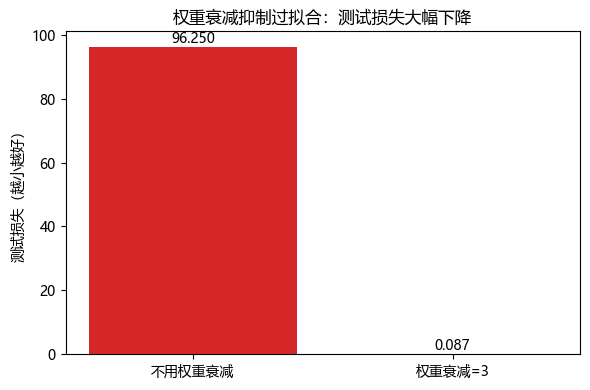

In [3]:
# ---- 简洁实现：optim.SGD 的 weight_decay 参数 ----
def train_concise(wd):
    net = torch.nn.Sequential(torch.nn.Linear(num_inputs, 1))
    for p in net.parameters(): p.data.normal_()
    loss = torch.nn.MSELoss(reduction='none')
    trainer = torch.optim.SGD([{"params": net[0].weight, "weight_decay": wd},
                               {"params": net[0].bias}], lr=0.003)
    num_epochs = 100
    for epoch in range(num_epochs):
        for X, y in data_iter(train_features, train_labels, batch_size):
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
    return loss(net(test_features), test_labels).mean().item()

简洁_无 = train_concise(0)
简洁_有 = train_concise(3)
print(f"简洁实现 · weight_decay=0：测试损失 {简洁_无:.4f}")
print(f"简洁实现 · weight_decay=3：测试损失 {简洁_有:.4f}")

# 可视化对比
fig, ax = plt.subplots(figsize=(6, 4))
方法 = ['不用权重衰减', '权重衰减=3']
测试损失 = [loss_无[1], loss_有[1]]
bars = ax.bar(方法, 测试损失, color=[红, 绿])
ax.set_ylabel('测试损失（越小越好）')
ax.set_title('权重衰减抑制过拟合：测试损失大幅下降')
for b, v in zip(bars, 测试损失):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.3f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()


## 第二部分 · Dropout（暂退法）

### 思想：训练时随机「关掉」一部分神经元

Dropout 在**每次训练前向**时，以概率 `p` 随机把某些神经元的输出置 0（相当于临时删掉这些神经元），逼网络**不依赖任何一个神经元**。推理（测试）时**所有神经元都参与**，所以要在训练时把保留的神经元输出**除以 `1-p`** 保持期望一致。

> 🔑 **记忆**：Dropout 只在**训练时**用，测试时关闭；保留的输出要 `/(1-p)` 补偿幅度。


In [4]:
# ---- 从零实现 Dropout 层 ----
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1             # assert是条件语句，True则继续；False则终止报错
    if dropout == 1:                     # 全丢：输出全 0
        return torch.zeros_like(X)
    if dropout == 0:                     # 不丢：原样输出
        return X
    mask = (torch.rand(X.shape) > dropout).float()   # 每个位置以 1-p 的概率保留；rand是生成【0，1）的随机数
    return mask * X / (1.0 - dropout)                # 除以 1-p 补偿，保持期望不变

# 演示：输入 8 个数，dropout=0.5，看哪几个被「关掉」
torch.manual_seed(3)
X = torch.arange(8, dtype=torch.float32).reshape(1, 8)
print("输入      ：", X.numpy())
print("dropout 后：", dropout_layer(X, 0.5).numpy())
print("→ 被置 0 的位置就是「被随机丢弃」的神经元；其余值 ×2 补偿。")


输入      ： [[0. 1. 2. 3. 4. 5. 6. 7.]]
dropout 后： [[ 0.  0.  0.  0.  0.  0. 12. 14.]]
→ 被置 0 的位置就是「被随机丢弃」的神经元；其余值 ×2 补偿。


### 用 Dropout 的 MLP：在 Fashion-MNIST 上从零实现

给上一节的 MLP 加两个 Dropout 层（隐藏层后、输出层前），`dropout` 概率是超参数，常用 0.2~0.5。


In [5]:
# ---- 从零实现带 Dropout 的 MLP ----
from torchvision import datasets, transforms
from torch.utils import data

def load_data_fashion_mnist(batch_size, root='../data'):
    trans = transforms.ToTensor()
    tr = datasets.FashionMNIST(root=root, train=True,  transform=trans, download=True)
    te = datasets.FashionMNIST(root=root, train=False, transform=trans, download=True)
    return data.DataLoader(tr, batch_size, shuffle=True), data.DataLoader(te, batch_size, shuffle=False)

train_iter, test_iter = load_data_fashion_mnist(256)

num_inputs, num_hiddens, num_outputs = 784, 256, 10
W1 = torch.normal(0, 0.01, (num_inputs, num_hiddens), requires_grad=True)
b1 = torch.zeros(num_hiddens, requires_grad=True)
W2 = torch.normal(0, 0.01, (num_hiddens, num_hiddens), requires_grad=True)
b2 = torch.zeros(num_hiddens, requires_grad=True)
W3 = torch.normal(0, 0.01, (num_hiddens, num_outputs), requires_grad=True)
b3 = torch.zeros(num_outputs, requires_grad=True)
params = [W1, b1, W2, b2, W3, b3]

def relu(X): return torch.max(X, torch.zeros_like(X))
def softmax(X):
    X_exp = torch.exp(X - X.max(dim=1, keepdim=True).values)
    return X_exp / X_exp.sum(dim=1, keepdim=True)
def cross_entropy(y_hat, y): return -torch.log(y_hat[range(len(y_hat)), y])
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1: y_hat = y_hat.argmax(axis=1)
    return float((y_hat.type(y.dtype) == y).sum())
def sgd(params, lr, batch_size):
    with torch.no_grad():
        for p in params:
            p -= lr * p.grad / batch_size
            p.grad.zero_()

dropout1, dropout2 = 0.2, 0.5   # 两个 dropout 概率

def net(X, is_training=True):
    X = X.reshape((-1, num_inputs))
    H1 = relu(X @ W1 + b1)
    if is_training:                      # 🔑 只在训练时 dropout
        H1 = dropout_layer(H1, dropout1)
    H2 = relu(H1 @ W2 + b2)
    if is_training:
        H2 = dropout_layer(H2, dropout2)
    return softmax(H2 @ W3 + b3)

lr, num_epochs = 0.1, 10
for epoch in range(num_epochs):
    for X, y in train_iter:
        l = cross_entropy(net(X, True), y); l.sum().backward(); sgd(params, lr, 256)
    with torch.no_grad():
        命中, 总数 = 0.0, 0
        for X, y in train_iter:
            命中 += accuracy(net(X, False), y); 总数 += y.numel()
        print(f"epoch {epoch+1:2d}: 训练准确率 {命中/总数:.4f}")


ModuleNotFoundError: No module named 'torchvision'

## 第三部分 · Dropout 的简洁实现

`nn.Dropout(p)` 一行搞定，它会**自动判断**训练/推理模式（`model.train()` 时开、`model.eval()` 时关）。


In [6]:
# ---- 简洁实现 Dropout ----
from torch import nn
net2 = nn.Sequential(nn.Flatten(),
                     nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.2),
                     nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.5),
                     nn.Linear(256, 10))
def init_weights(m):
    if type(m) == nn.Linear: nn.init.normal_(m.weight, std=0.01)
net2.apply(init_weights)

loss = nn.CrossEntropyLoss()
trainer = torch.optim.SGD(net2.parameters(), lr=0.1)

for epoch in range(num_epochs):
    net2.train()                          # 训练模式：Dropout 生效
    for X, y in train_iter:
        l = loss(net2(X), y); trainer.zero_grad(); l.backward(); trainer.step()
    net2.eval()                           # 推理模式：Dropout 关闭
    with torch.no_grad():
        命中, 总数 = 0.0, 0
        for X, y in train_iter:
            命中 += float((net2(X).argmax(axis=1) == y).sum()); 总数 += y.numel()
    print(f"epoch {epoch+1:2d}: 训练准确率 {命中/总数:.4f}")

net2.eval()
with torch.no_grad():
    命中, 总数 = 0.0, 0
    for X, y in test_iter:
        命中 += float((net2(X).argmax(axis=1) == y).sum()); 总数 += y.numel()
print(f"\n带 Dropout 的 MLP 测试集准确率：{命中/总数:.4f}")


NameError: name 'num_epochs' is not defined